In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import xarray as xr

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from neuralop.models.local_no import LocalNO
from neuralop.models import UNO
from neuralop.layers.spectral_convolution import SpectralConv

from tabulate import tabulate

torch.serialization.add_safe_globals([torch.nn.functional.gelu])

In [ ]:
class ContinuousBasisConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, radii=[1, 2, 3], h=1.0, is_differential=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.radii = radii
        self.num_bases = len(radii) 
        self.h = h
        self.is_differential = is_differential
        
        max_r = max(radii)
        self.padding = (0, max_r, max_r) 

        grid_t, grid_y, grid_x = torch.meshgrid(
            torch.arange(0, 1),
            torch.arange(-max_r, max_r + 1),
            torch.arange(-max_r, max_r + 1),
            indexing='ij'
        )
        self.register_buffer('grid_t', grid_t.float())
        self.register_buffer('grid_y', grid_y.float())
        self.register_buffer('grid_x', grid_x.float())

        self.time_scale = nn.Parameter(torch.tensor(1.0))
        
        init_p = [radii[i % len(radii)] for i in range(self.num_bases)]
        self.basis_params = nn.Parameter(torch.tensor(init_p, dtype=torch.float32))
        
        # 
        self.angle = nn.Parameter(torch.zeros(self.num_bases))
        self.scale_x = nn.Parameter(torch.ones(self.num_bases) + torch.randn(self.num_bases) * 0.05)
        self.scale_y = nn.Parameter(torch.ones(self.num_bases) + torch.randn(self.num_bases) * 0.05)
        # 
        
        fan_in = in_channels * (1 * (2*max_r+1) * (2*max_r+1))
        std = (2.0 / fan_in) ** 0.5
        self.basis_weights = nn.Parameter(torch.randn(out_channels, in_channels, self.num_bases) * std)

    def generate_kernel(self):
        dx = self.grid_x * self.h
        dy = self.grid_y * self.h
        dt = self.grid_t * self.time_scale
        
        #
        theta = self.angle.view(-1, 1, 1, 1)
        sx = torch.clamp(torch.abs(self.scale_x), min=0.1).view(-1, 1, 1, 1)
        sy = torch.clamp(torch.abs(self.scale_y), min=0.1).view(-1, 1, 1, 1)
        

        # [cos(theta) -sin(theta); sin(theta) cos(theta)]
        # поворот сетки координат на угол theta
        dx_rot = dx.unsqueeze(0) * torch.cos(theta) - dy.unsqueeze(0) * torch.sin(theta)
        dy_rot = dx.unsqueeze(0) * torch.sin(theta) + dy.unsqueeze(0) * torch.cos(theta)
        
        # Растягиваем/сжимаем оси (эллипс)
        dx_new = dx_rot / sx
        dy_new = dy_rot / sy
        dt_new = dt.unsqueeze(0) * self.time_scale
        
        r_sq = dt_new**2 + dx_new**2 + dy_new**2
        r = torch.sqrt(r_sq + 1e-8)
    
        p = torch.clamp(torch.abs(self.basis_params), min=0.1).view(-1, 1, 1, 1)
    
        r_norm = r / p
        relu_part = F.relu(1.0 - r_norm)
        bases_tensor = (relu_part ** 4) * (4 * r_norm + 1.0)
        
        kernel = torch.einsum('oib, btyx -> oityx', self.basis_weights, bases_tensor)
        kernel = kernel / np.sqrt(self.num_bases)
        
        kernel = kernel * (self.h ** 2)
        
        if self.is_differential:
            kernel_mean = kernel.mean(dim=(2, 3, 4), keepdim=True)
            kernel = kernel - kernel_mean
            kernel = kernel / (self.h ** 2 + 1e-8)
            
        return kernel

    def forward(self, x):
        weight = self.generate_kernel()
        
        if weight.shape[2] == 1:
            B, C, T, Y, X = x.shape
            weight_2d = weight.squeeze(2)
            x_2d = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, Y, X)
            pad_y, pad_x = self.padding[1], self.padding[2]
            
            out_2d = F.conv2d(x_2d, weight_2d, bias=None, padding=(pad_y, pad_x))
            out = out_2d.reshape(B, T, self.out_channels, Y, X).permute(0, 2, 1, 3, 4)
            return out
        else:
            return F.conv3d(x, weight, bias=None, padding=self.padding)

In [ ]:
class TrueLocalNOBlock3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes, radii=[1, 2, 3], use_integral=True):
        super().__init__()
        self.use_integral = use_integral
        self.fno_conv = SpectralConv(in_channels=in_channels, out_channels=out_channels, n_modes=modes)
        
        if self.use_integral:
            self.local_integral = ContinuousBasisConv3d(in_channels, out_channels, radii=radii, is_differential=False)
            
        self.local_differential = ContinuousBasisConv3d(in_channels, out_channels, radii=radii, is_differential=True)
        
        self.skip = nn.Conv3d(in_channels, out_channels, kernel_size=1)
        self.norm = nn.InstanceNorm3d(out_channels)
        self.activation = nn.GELU()
        
        num_branches = 4 if self.use_integral else 3
        self.fusion_weights = nn.Parameter(torch.ones(num_branches)) 

    def forward(self, x, mask=None):
        identity = x 
        w = torch.softmax(self.fusion_weights, dim=0)
        
        out_fno = self.fno_conv(x)
        out_diff = self.local_differential(x)
        out_skip = self.skip(x)
        
        if self.use_integral:
            out_int = self.local_integral(x)
            out = (w[0] * out_fno + w[1] * out_int + w[2] * out_diff + w[3] * out_skip)
        else:
            out = (w[0] * out_fno + w[1] * out_diff + w[2] * out_skip)
            
        out = self.norm(identity + out)
        
        if mask is not None:
            out = out * mask
        return self.activation(out)


class CustomLocalNO3d(nn.Module):
    def __init__(self, in_channels=2, out_channels=1, hidden_channels=32, n_layers=4, 
                 modes=(10, 20, 20), radii=[1, 2, 3], use_integral=True):
        super().__init__()
        self.lift = nn.Conv3d(in_channels, hidden_channels, kernel_size=1)
        
        self.blocks = nn.ModuleList([
            TrueLocalNOBlock3d(in_channels=hidden_channels, out_channels=hidden_channels, 
                               modes=modes, radii=radii, use_integral=use_integral) 
            for _ in range(n_layers)
        ])
        
        self.project = nn.Sequential(
            nn.Conv3d(hidden_channels, hidden_channels, kernel_size=1),
            nn.GELU(),
            nn.Conv3d(hidden_channels, out_channels, kernel_size=1)
        )

    def forward(self, x, mask=None):
        x = self.lift(x)
        if mask is not None: x = x * mask
            
        for block in self.blocks:
            x = block(x, mask=mask)
            
        x = self.project(x)
        return x

In [4]:
CURRENT_DIRECTORY = f'/../horizontal_correct/'
DATA_PATH = f'data'
ASSETS_PATH = f'assets'
MODELS_PATH = f'models'

filepaths =[f'{DATA_PATH}/source_{i}.hdf5' for i in range(1, 4)]

dim_map = {
    'phony_dim_0' : 'time',
    'phony_dim_1' : 'sample',
    'phony_dim_2' : 'channel',
    'phony_dim_3' : 'Y',
    'phony_dim_4' : 'X'
}

In [5]:
def preprocess(path):
    print(f'Открытие датасета : {path}')
    ds = xr.open_dataset(path, engine='h5netcdf', phony_dims='sort').rename(dim_map)
    pressure = ds.dataset.isel(channel=0)
    source = ds.source
    return xr.Dataset({'pressure': pressure, 'source':source}, attrs=ds.attrs)

print("Загрузка данных...")
processed_datasets = [preprocess(f) for f in filepaths]
final_ds = xr.concat(processed_datasets, dim='sample').squeeze('phony_dim_5')

Загрузка данных...
Открытие датасета : data/source_1.hdf5
Открытие датасета : data/source_2.hdf5
Открытие датасета : data/source_3.hdf5


In [ ]:
raw_p = final_ds.pressure.values
mask_2d = ~np.isnan(raw_p[0, 0])

p_min, p_max = np.nanmin(raw_p), np.nanmax(raw_p)
norm_p = np.zeros_like(raw_p, dtype='float32')
norm_p[:, :, mask_2d] = (raw_p[:, :, mask_2d] - p_min) / (p_max - p_min)

s_raw = final_ds.source.values.copy()
s_raw[..., ~mask_2d] = 0 
s_abs_max = np.max(np.abs(s_raw))
norm_s = (s_raw / s_abs_max).astype('float32') if s_abs_max != 0 else s_raw

In [7]:
P_tensor = torch.from_numpy(norm_p).permute(1, 0, 2, 3).float()
S_tensor = torch.from_numpy(norm_s).float()
X_final = torch.stack([P_tensor, S_tensor], dim=2)
STATIC_MASK = torch.from_numpy(mask_2d.astype('float32'))

In [8]:
def get_indices(size, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    np.random.seed(2318)
    indices = np.arange(size)
    np.random.shuffle(indices)
    train_end = int(size * train_ratio)
    val_end = train_end + int(size * val_ratio)
    return indices[:train_end], indices[train_end:val_end], indices[val_end:]

In [9]:
class SpatiotemporalDataset(Dataset):
    def __init__(self, data, indices):
        self.data = data[indices] 
        self.N_samples = self.data.shape[0]
        self.T_total = self.data.shape[1]
        self.T_future = self.T_total - 1

    def __len__(self):
        return self.N_samples

    def __getitem__(self, idx):
        p_init = self.data[idx, 0, 0] 
        p_init_cube = p_init.unsqueeze(0).repeat(self.T_future, 1, 1)
        s_future_cube = self.data[idx, 1:, 1]
        x = torch.stack([p_init_cube, s_future_cube], dim=0)
        y = self.data[idx, 1:, 0].unsqueeze(0)
        return x, y

In [12]:
def train_model(modes, 
                hidden_channels,
                n_layers,
                train_loader, 
                val_loader, 
                device, 
                static_mask, 
                epochs=200,
                well_penalty=10.0, 
                radii=[1, 2, 3], 
                use_integral=True
    ):
    
    torch.backends.cudnn.benchmark = True 
    
    model = CustomLocalNO3d(
        in_channels=2, 
        out_channels=1, 
        hidden_channels=hidden_channels, 
        n_layers=n_layers, 
        modes=modes, 
        radii=radii, 
        use_integral=use_integral
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3) 
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)
    
    mask = static_mask.to(device).float()
    mask_3d = mask.unsqueeze(0).unsqueeze(0).unsqueeze(0) 
    
    best_val_l2 = float('inf')
    
    status_int = "with_int" if use_integral else "no_int"
    best_model_path = f"LocalNO_Wendland_b3_hc32_{status_int}_angle.pth" 
    patience_counter = 0

    print(f"=== TRAINING | Radii: {radii}  | Integral Branch : {use_integral} ===")

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            x_in, y_true =[b.to(device) for b in batch]
            optimizer.zero_grad()
            
            pred = model(x_in, mask=mask_3d) 
            
            wells_cube = x_in[:, 1:2] 
            well_mask = (torch.abs(wells_cube) > 1e-5).float()
            weight_map = torch.ones_like(pred) + (well_mask * (well_penalty - 1.0))
            
            error = (pred - y_true) * mask_3d
            loss = ((error ** 2) * weight_map).mean()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item() * x_in.size(0)
            
        epoch_train_loss = total_train_loss / len(train_loader.dataset)

        model.eval()
        val_l2_errors =[]
        with torch.no_grad():
            for batch_v in val_loader:
                x_v, y_v =[b.to(device) for b in batch_v]
                pred_v = model(x_v, mask=mask_3d) 
                
                pred_v = pred_v * mask_3d
                true_v = y_v * mask_3d
                
                diff_norm = torch.norm((pred_v - true_v).reshape(x_v.size(0), -1), p=2, dim=1).float()
                true_norm = torch.norm(true_v.reshape(x_v.size(0), -1), p=2, dim=1).float()
                rel_l2 = (diff_norm / torch.clamp(true_norm, min=1e-8)) * 100
                val_l2_errors.extend(rel_l2.cpu().numpy())

        epoch_mean = np.mean(val_l2_errors)
        scheduler.step(epoch_mean) 
        
        current_lr = optimizer.param_groups[0]['lr']
        if epoch_mean < best_val_l2:
            best_val_l2 = epoch_mean
            torch.save(model.state_dict(), best_model_path)
            status = "<--- save"
            patience_counter = 0
        else:
            status = f"[Wait {patience_counter+1}]"
            patience_counter += 1
            
        print(f"Epoch {epoch+1:03d} | LR: {current_lr:.2e} | Train Loss: {epoch_train_loss:.6f} | Val L2: {epoch_mean:.2f}% {status}")

        if patience_counter >= 30:
            print("=== EARLY STOPPING ===")
            break

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    return model

In [13]:
GPU_ID = "cuda:2"
RADII =[1, 2, 3]
WELL_PENALTY = 10.0

MODES_3D = (10, 24, 24)
HIDDEN_CHANNELS = 32
N_LAYERS = 4
EPOCHS = 150
BATCH_SIZE = 2

device = GPU_ID if torch.cuda.is_available() else "cpu"

train_idx, val_idx, test_idx = get_indices(X_final.shape[0])

train_ds = SpatiotemporalDataset(X_final, train_idx)
val_ds = SpatiotemporalDataset(X_final, val_idx)
test_ds = SpatiotemporalDataset(X_final, test_idx)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

best_model = train_model(
    modes=MODES_3D,
    hidden_channels=HIDDEN_CHANNELS, 
    n_layers=N_LAYERS,
    train_loader=train_loader, 
    val_loader=val_loader,
    static_mask=STATIC_MASK, 
    device=device, 
    epochs=EPOCHS,
    well_penalty=WELL_PENALTY, 
    radii=RADII,
    use_integral=True
)

=== TRAINING | Radii: [1, 2, 3]  | Integral Branch : True ===
Epoch 001 | LR: 5.00e-04 | Train Loss: 0.009697 | Val L2: 25.68% <--- save
Epoch 002 | LR: 5.00e-04 | Train Loss: 0.005046 | Val L2: 22.00% <--- save
Epoch 003 | LR: 5.00e-04 | Train Loss: 0.003791 | Val L2: 18.56% <--- save
Epoch 004 | LR: 5.00e-04 | Train Loss: 0.003017 | Val L2: 17.25% <--- save
Epoch 005 | LR: 5.00e-04 | Train Loss: 0.002564 | Val L2: 15.90% <--- save
Epoch 006 | LR: 5.00e-04 | Train Loss: 0.002217 | Val L2: 14.90% <--- save
Epoch 007 | LR: 5.00e-04 | Train Loss: 0.002007 | Val L2: 14.19% <--- save
Epoch 008 | LR: 5.00e-04 | Train Loss: 0.001824 | Val L2: 14.19% [Wait 1]
Epoch 009 | LR: 5.00e-04 | Train Loss: 0.001689 | Val L2: 14.09% <--- save
Epoch 010 | LR: 5.00e-04 | Train Loss: 0.001546 | Val L2: 12.54% <--- save
Epoch 011 | LR: 5.00e-04 | Train Loss: 0.001375 | Val L2: 11.97% <--- save
Epoch 012 | LR: 5.00e-04 | Train Loss: 0.001210 | Val L2: 10.92% <--- save
Epoch 013 | LR: 5.00e-04 | Train Loss: 

In [15]:
def analyze_results(model, test_loader, device, static_mask, num_plots=5):
    model.eval()
    mask_3d = static_mask.to(device).float().unsqueeze(0).unsqueeze(0).unsqueeze(0)
    
    global_errors, well_errors = [],[]
    plots_done = 0

    with torch.no_grad():
        for batch in test_loader:
            x_in, y_true = [b.to(device) for b in batch]
            
            pred = model(x_in, mask=mask_3d) 
            
            pred = pred * mask_3d
            true = y_true * mask_3d
            
            wells_cube = x_in[:, 1:2] 
            well_mask = (torch.abs(wells_cube) > 1e-5).float() * mask_3d
            
            for i in range(x_in.shape[0]):
                p_p, p_t, w_m = pred[i], true[i], well_mask[i]
                
                g_err = (torch.norm(p_p - p_t) / (torch.norm(p_t) + 1e-8)) * 100
                global_errors.append(g_err.item())
                
                if w_m.sum() > 0:
                    w_err = (torch.norm((p_p - p_t)*w_m) / (torch.norm(p_t*w_m) + 1e-8)) * 100
                    well_errors.append(w_err.item())

                if plots_done < num_plots:
                    t_mid = p_t.shape[1] // 2
                    true_np = p_t[0, t_mid].cpu().numpy()
                    pred_np = p_p[0, t_mid].cpu().numpy()
                    wells_np = wells_cube[i, 0, t_mid].cpu().numpy()
                    
                    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
                    cbar_kwargs = {'fraction': 0.046, 'pad': 0.04}

                    val_min = min(true_np.min(), pred_np.min())
                    val_max = max(true_np.max(), pred_np.max())

                    im0 = axes[0].imshow(wells_np, cmap='bwr')
                    axes[0].set_title(f"Скважины (t={t_mid})", fontsize=14)
                    fig.colorbar(im0, ax=axes[0], **cbar_kwargs)

                    im1 = axes[1].imshow(true_np, cmap='jet', vmin=val_min, vmax=val_max)
                    axes[1].set_title(f"Истинное давление (t={t_mid})", fontsize=14)
                    fig.colorbar(im1, ax=axes[1], **cbar_kwargs)

                    im2 = axes[2].imshow(pred_np, cmap='jet', vmin=val_min, vmax=val_max)
                    axes[2].set_title(f"Предсказание (t={t_mid})", fontsize=14)
                    fig.colorbar(im2, ax=axes[2], **cbar_kwargs)

                    max_true = np.max(np.abs(true_np)) if np.max(np.abs(true_np)) > 1e-8 else 1.0
                    rel_err_map = np.clip((np.abs(true_np - pred_np) / max_true) * 100, 0, 100)
                    
                    bounds =[0, 1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100]
                    cmap_error = plt.get_cmap('turbo')
                    norm_error = mcolors.BoundaryNorm(bounds, cmap_error.N)
                    
                    im3 = axes[3].imshow(rel_err_map, cmap=cmap_error, norm=norm_error)
                    axes[3].set_title("Процентная ошибка (%)", fontsize=14)
                    
                    fig.colorbar(im3, ax=axes[3], boundaries=bounds, ticks=bounds, spacing='uniform', **cbar_kwargs)
                    
                    for ax in axes: 
                        ax.set_xticks([])
                        ax.set_yticks([])
                        
                    plt.tight_layout()
                    plt.show()
                    
                    plots_done += 1
                    if plots_done >= num_plots: break

    print(f"Средняя глобальная ошибка на тесте: {np.mean(global_errors):.2f}%")
    print(f"Средняя ошибка В СКВАЖИНАХ на тесте: {np.mean(well_errors):.2f}%")

def generate_and_save_gif(model, test_loader, device, static_mask, filename="aboba.gif"):
    model.eval()
    
    batch = next(iter(test_loader))
    x_in, y_true = [b.to(device) for b in batch]
    mask_3d = static_mask.to(device).float()
    
    with torch.no_grad():
        pred = model(x_in, mask=mask_3d.unsqueeze(0).unsqueeze(0).unsqueeze(0))
        pred = pred * mask_3d.unsqueeze(0).unsqueeze(0).unsqueeze(0)
        y_true = y_true * mask_3d.unsqueeze(0).unsqueeze(0).unsqueeze(0)
    
    t0_true = x_in[0, 0, 0].cpu()
    true_seq = torch.cat([t0_true.unsqueeze(0), y_true[0, 0].cpu()], dim=0).numpy()
    pred_seq = torch.cat([t0_true.unsqueeze(0), pred[0, 0].cpu()], dim=0).numpy()
    
    wells_future = x_in[0, 1].cpu()
    wells_seq = torch.cat([wells_future[0].unsqueeze(0), wells_future], dim=0).numpy()

    T = true_seq.shape[0]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    
    val_min = min(np.min(true_seq), np.min(pred_seq))
    val_max = max(np.max(true_seq), np.max(pred_seq))
    cbar_kwargs = {'fraction': 0.046, 'pad': 0.04}
    
    bounds =[0, 1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100]
    cmap_error = plt.get_cmap('turbo')
    norm_error = mcolors.BoundaryNorm(bounds, cmap_error.N)
    
    im0 = axes[0].imshow(wells_seq[0], cmap='bwr')
    im1 = axes[1].imshow(true_seq[0], cmap='jet', vmin=val_min, vmax=val_max)
    im2 = axes[2].imshow(pred_seq[0], cmap='jet', vmin=val_min, vmax=val_max)
    im3 = axes[3].imshow(np.zeros_like(true_seq[0]), cmap=cmap_error, norm=norm_error)
    
    axes[0].set_title("Скважины", fontsize=14)
    axes[1].set_title("Истинное давление", fontsize=14)
    axes[2].set_title("Предсказание модели", fontsize=14)
    axes[3].set_title("Процентная ошибка (%)", fontsize=14)
    
    fig.colorbar(im0, ax=axes[0], **cbar_kwargs)
    fig.colorbar(im1, ax=axes[1], **cbar_kwargs)
    fig.colorbar(im2, ax=axes[2], **cbar_kwargs)
    fig.colorbar(im3, ax=axes[3], boundaries=bounds, ticks=bounds, spacing='uniform', **cbar_kwargs)
    
    for ax in axes: 
        ax.set_xticks([])
        ax.set_yticks([])
        
    time_text = fig.suptitle("Инициализация...", fontsize=16, fontweight='bold')

    def update(frame):
        im0.set_array(wells_seq[frame])
        im1.set_array(true_seq[frame])
        im2.set_array(pred_seq[frame])
        
        true_frame, pred_frame = true_seq[frame], pred_seq[frame]
        max_t = np.max(np.abs(true_frame)) if np.max(np.abs(true_frame)) > 1e-8 else 1.0
        rel_err_map = np.clip((np.abs(true_frame - pred_frame) / max_t) * 100, 0, 100)
        im3.set_array(rel_err_map)
        
        frame_err = (np.linalg.norm(pred_frame - true_frame) / (np.linalg.norm(true_frame) + 1e-8)) * 100
        time_text.set_text(f"Шаг {frame}/{T-1} | L2 Ошибка: {frame_err:.2f}%")
        return [im0, im1, im2, im3, time_text]

    ani = animation.FuncAnimation(fig, update, frames=T, interval=200, blit=False)
    ani.save(filename, writer='pillow', fps=5)
    plt.close(fig)
    print(f"Гифка сохранена как '{filename}'.")

gif_name = f"14_LocalNO_wendland_b3_hc32_angle_trajectory.gif"
generate_and_save_gif(best_model, test_loader, torch.device("cuda:2"), STATIC_MASK, filename=gif_name)

Гифка сохранена как '14_LocalNO_wendland_b3_hc32_angle_trajectory.gif'.


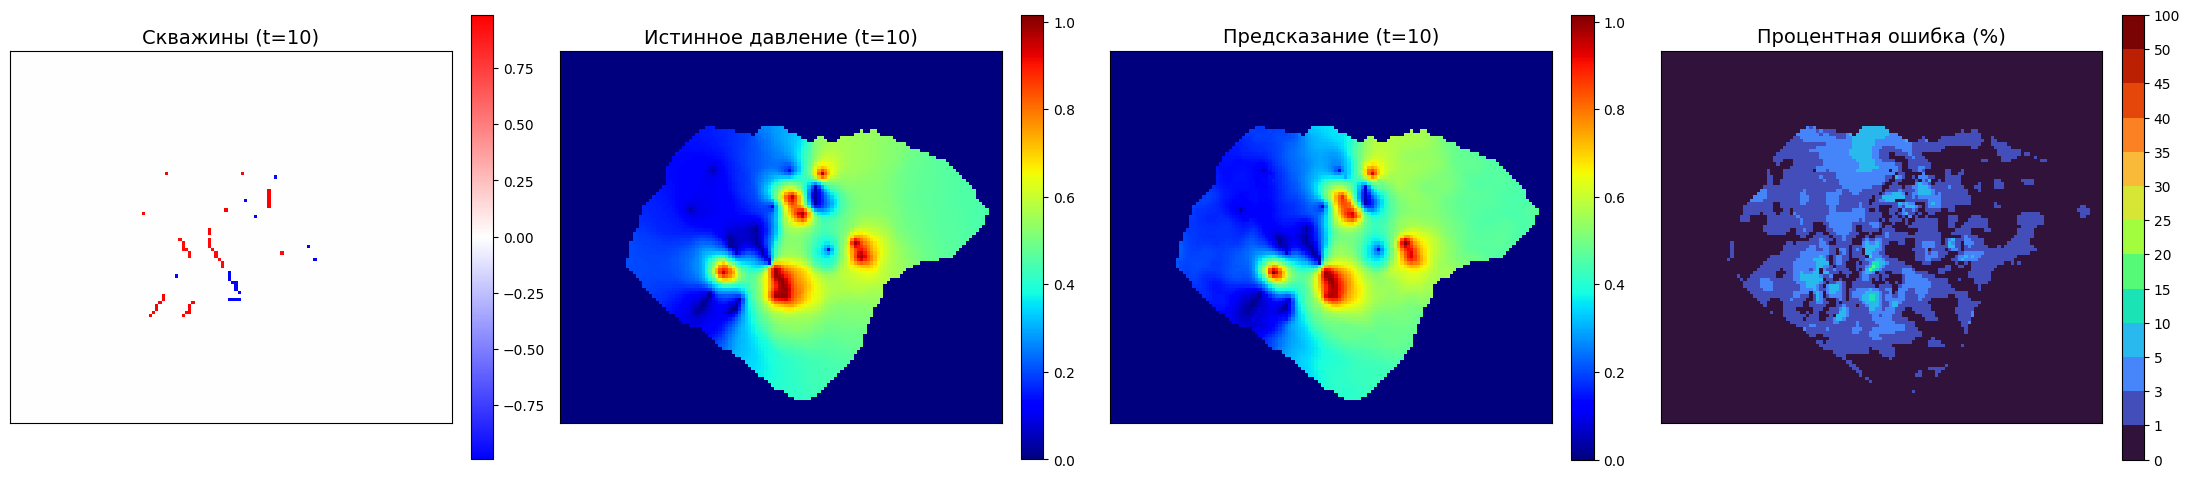

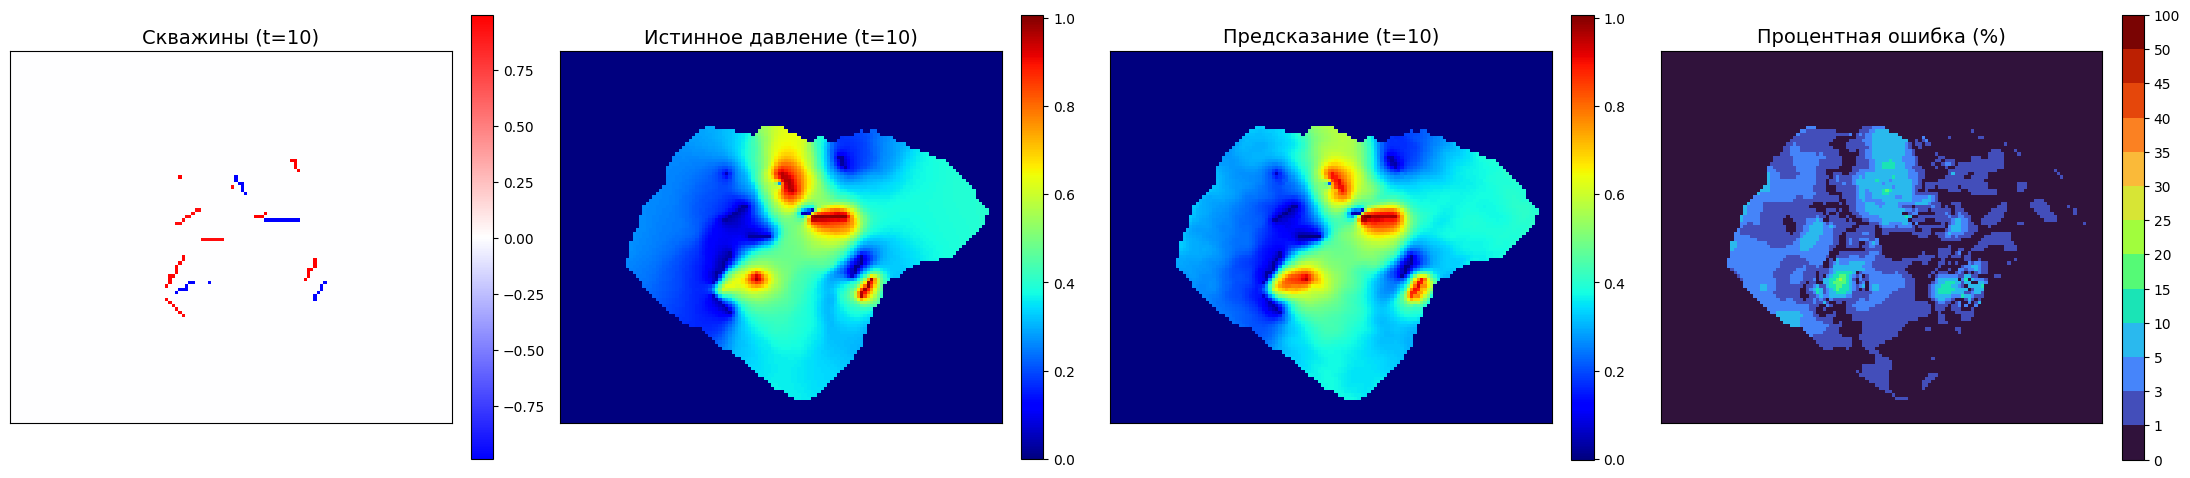

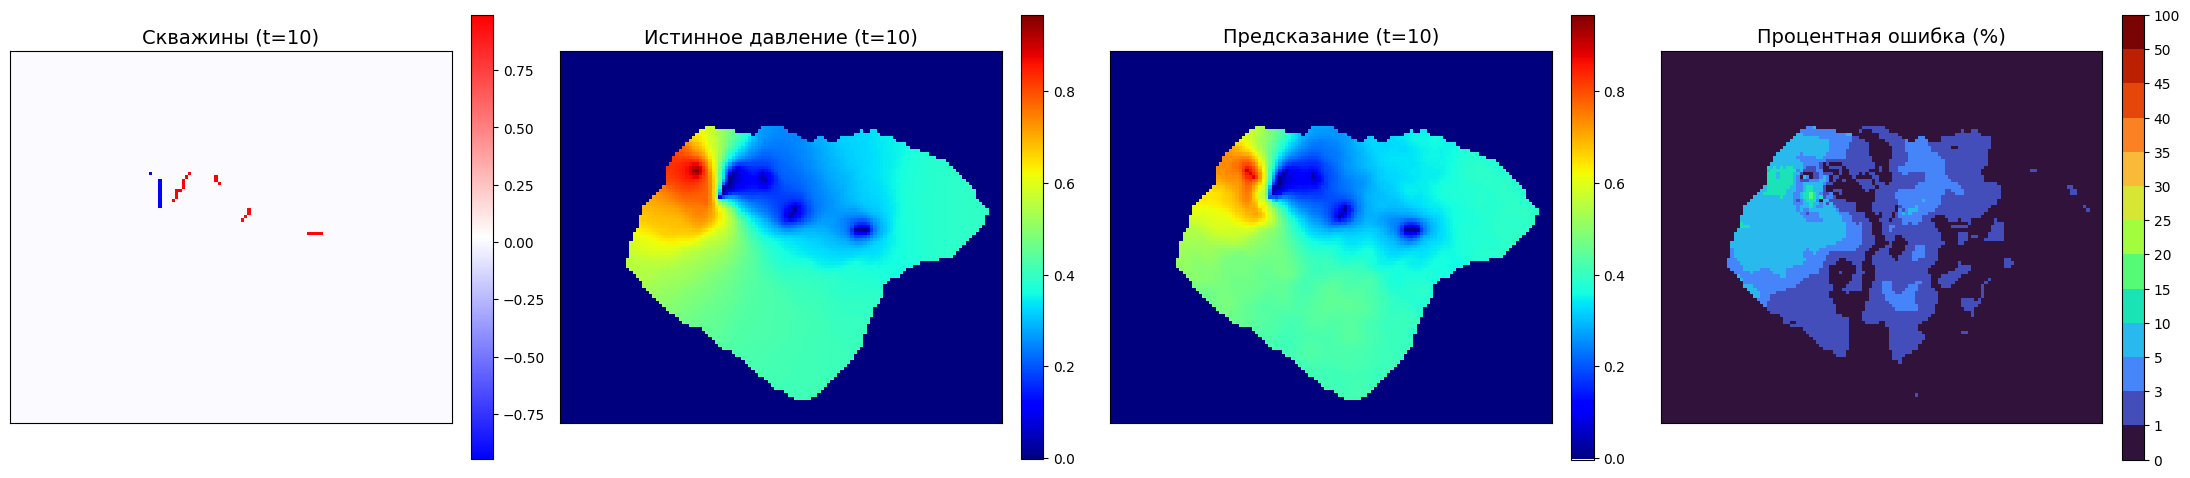

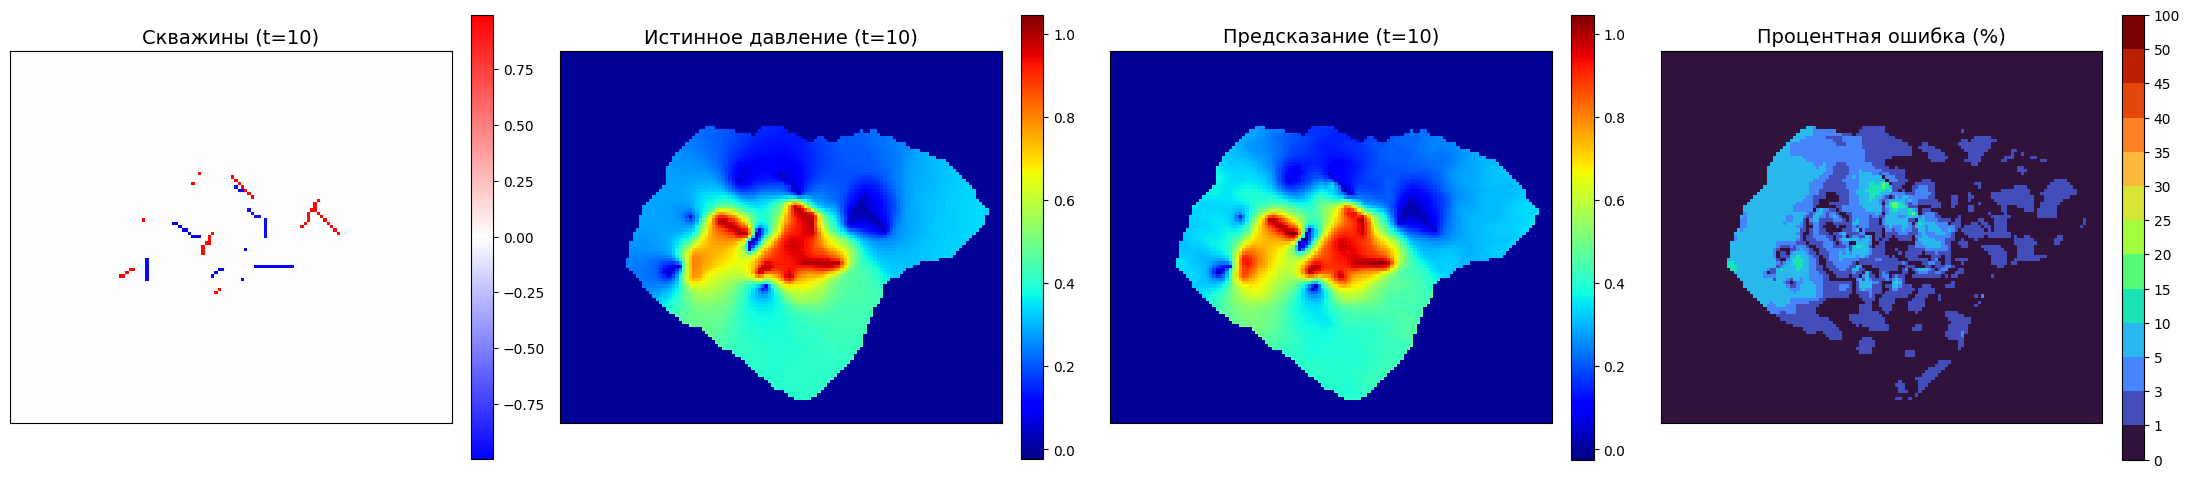

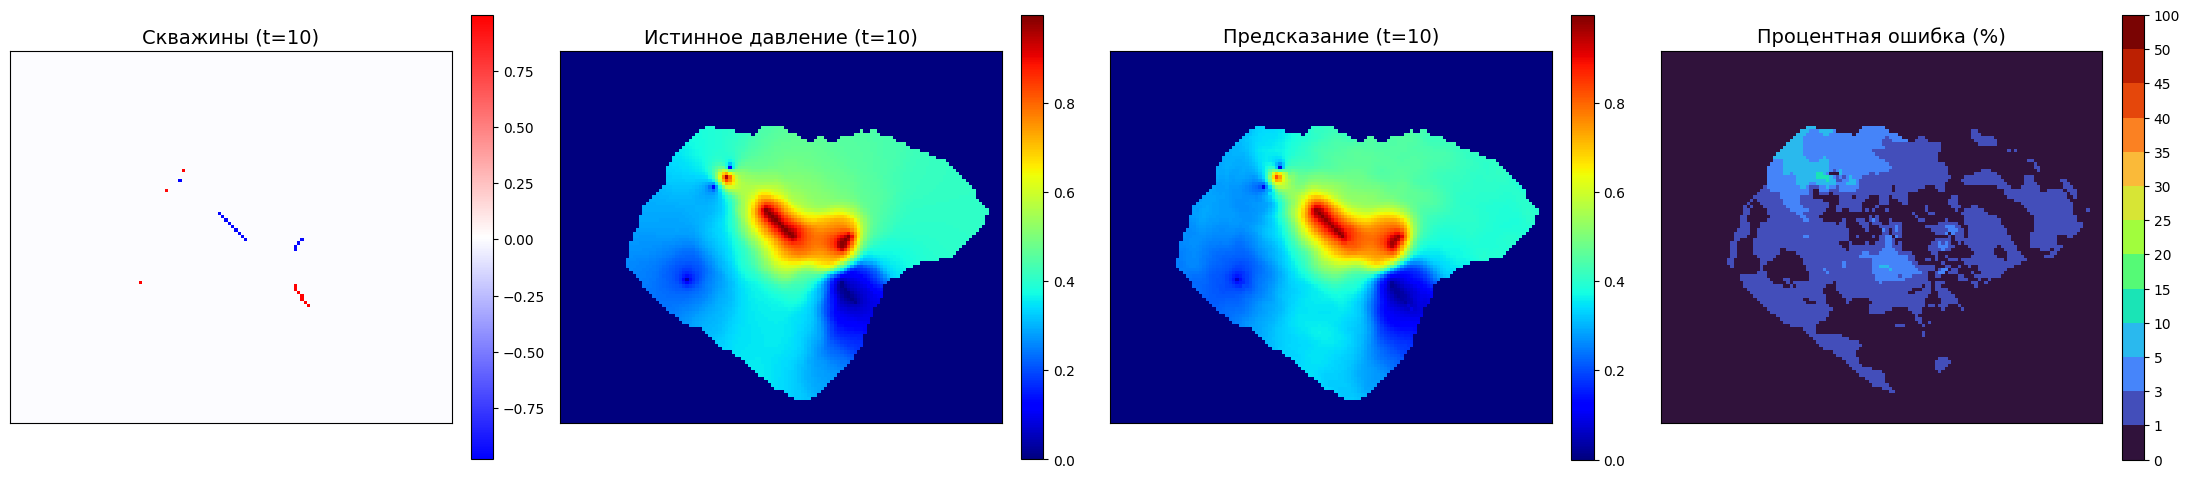

Средняя глобальная ошибка на тесте: 7.76%
Средняя ошибка В СКВАЖИНАХ на тесте: 9.98%


In [16]:
analyze_results(best_model, test_loader, device, STATIC_MASK, num_plots=5)

График весов сохранен в: 14_LocalNO_WendLand_b3_hc32_angle_weights.png


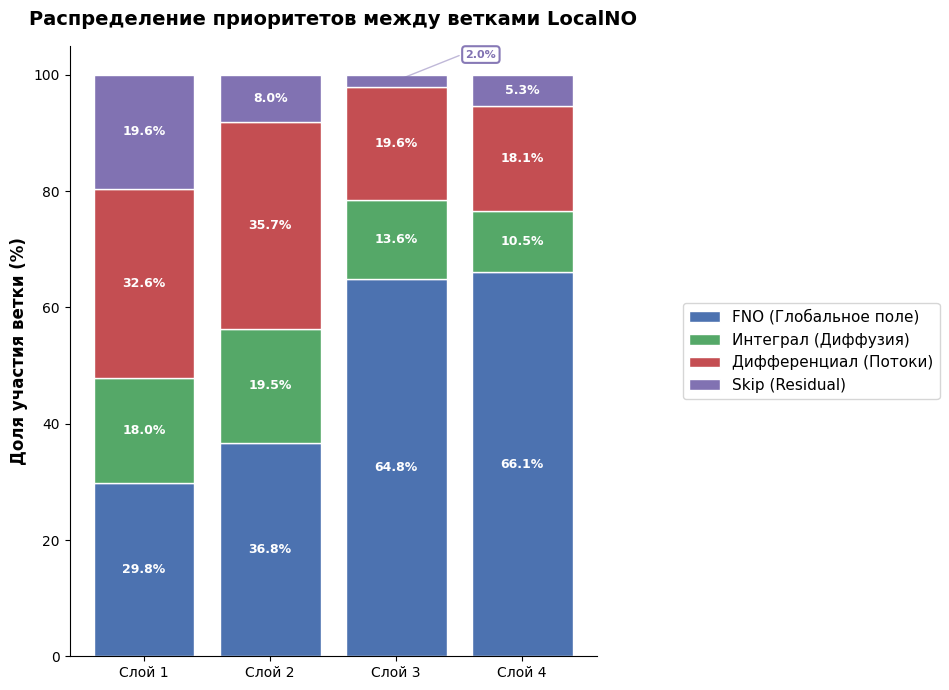

График радиусов сохранен в: 14_LocalNO_WendLand_b3_hc32_angle_radii.png


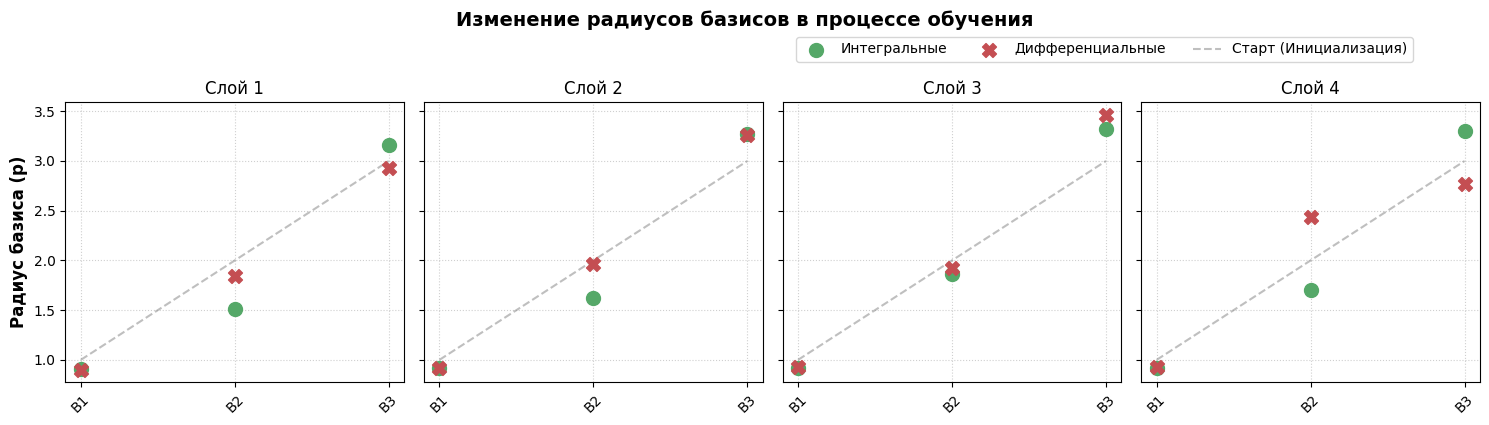

График углов сохранен в: 14_LocalNO_WendLand_b3_hc32_angle_angles.png


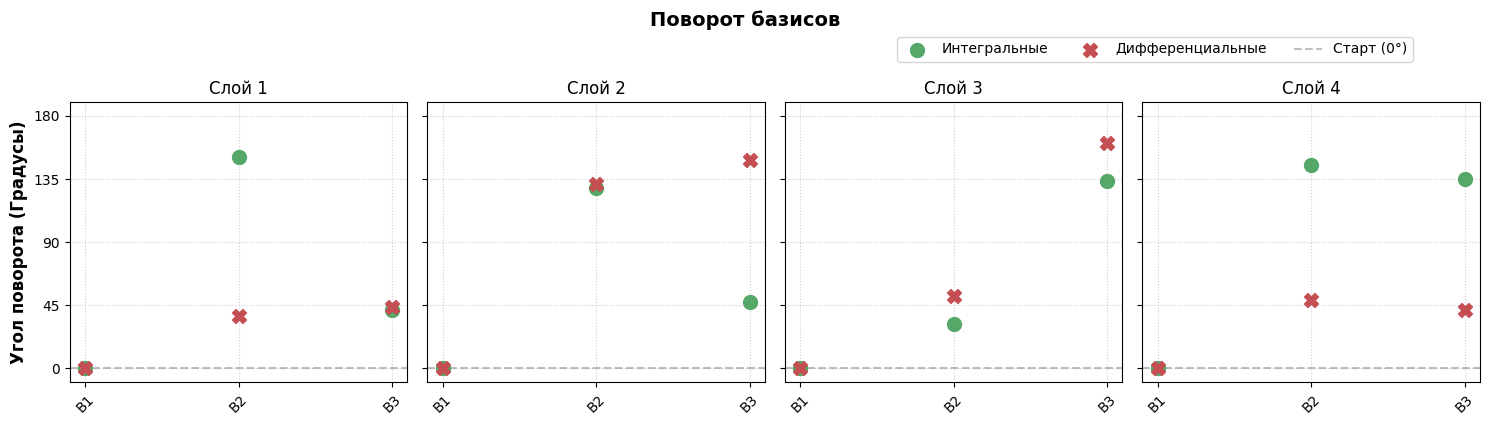

In [ ]:
def visualize_operator_weights(model, save_path_prefix="localno_plots"):
    
    n_layers = len(model.blocks)
    
    fusion_weights = np.zeros((n_layers, 4))
    
    for i, block in enumerate(model.blocks):
        fw = torch.softmax(block.fusion_weights.detach(), dim=0).cpu().numpy()
        fusion_weights[i] = fw

    fig, ax = plt.subplots(figsize=(12, 7))
    
    layers =[f"Слой {i+1}" for i in range(n_layers)]
    bottom = np.zeros(n_layers)
    
    labels =['FNO (Глобальное поле)', 'Интеграл (Диффузия)', 'Дифференциал (Потоки)', 'Skip (Residual)']
    colors =['#4c72b0', '#55a868', '#c44e52', '#8172b2']
    
    for j in range(4):
        bars = ax.bar(layers, fusion_weights[:, j] * 100, bottom=bottom, label=labels[j], color=colors[j], edgecolor='white')
        
        for idx, bar in enumerate(bars):
            height = bar.get_height()
            y_pos = bar.get_y() + height / 2
            
            if height > 3.0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    y_pos,
                    f'{height:.1f}%',
                    ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=9
                )
            
            elif height > 0.01:
                vertical_offset = (j - 1.5) * 3
                
                ax.text(
                    bar.get_x() + bar.get_width() + 0.15,
                    y_pos + vertical_offset,
                    f'{height:.1f}%' if height >= 0.1 else f'{height:.2f}%',
                    ha='left', va='center',
                    color=colors[j], fontweight='bold', 
                    fontsize=8 if height >= 0.1 else 7,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                             edgecolor=colors[j], linewidth=1.5, alpha=0.95)
                )
                
                ax.annotate('', xy=(bar.get_x() + bar.get_width() + 0.12, y_pos + vertical_offset),
                           xytext=(bar.get_x() + bar.get_width() / 2, y_pos),
                           arrowprops=dict(arrowstyle='-', color=colors[j], lw=1, alpha=0.5))
        
        bottom += fusion_weights[:, j] * 100

    ax.set_ylabel("Доля участия ветки (%)", fontsize=12, fontweight='bold')
    ax.set_title("Распределение приоритетов между ветками LocalNO", fontsize=14, fontweight='bold', pad=15)
    
    ax.legend(loc='center left', bbox_to_anchor=(1.15, 0.5), fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    fname1 = f"{save_path_prefix}_weights.png"
    plt.savefig(fname1, dpi=300, bbox_inches='tight')
    print(f"График весов сохранен в: {fname1}")
    plt.show()

    fig, axes = plt.subplots(1, n_layers, figsize=(15, 4), sharey=True)
    if n_layers == 1: axes = [axes]  
    
    for i, block in enumerate(model.blocks):
        p_int = torch.clamp(torch.abs(block.local_integral.basis_params), min=0.1).detach().cpu().numpy()
        p_diff = torch.clamp(torch.abs(block.local_differential.basis_params), min=0.1).detach().cpu().numpy()
        
        x_pos = np.arange(len(p_int))
        
        axes[i].scatter(x_pos, p_int, color='#55a868', s=100, label='Интегральные' if i==0 else "", zorder=3)
        axes[i].scatter(x_pos, p_diff, color='#c44e52', s=100, marker='X', label='Дифференциальные' if i==0 else "", zorder=3)
        
        init_radii = [1, 2, 3] * (len(p_int) // 3 + 1)
        axes[i].plot(x_pos, init_radii[:len(p_int)], linestyle='--', color='gray', alpha=0.5, label='Старт (Инициализация)' if i==0 else "")
        
        axes[i].set_title(f"Слой {i+1}", fontsize=12)
        axes[i].set_xticks(x_pos)
        axes[i].set_xticklabels([f"B{j+1}" for j in range(len(p_int))], rotation=45)
        axes[i].grid(True, linestyle=':', alpha=0.6, zorder=0)

    axes[0].set_ylabel("Радиус базиса (p)", fontsize=12, fontweight='bold')
    fig.suptitle("Изменение радиусов базисов в процессе обучения", fontsize=14, fontweight='bold', y=1.05)
    fig.legend(loc='upper right', bbox_to_anchor=(0.95, 1.0), ncol=3)
    
    plt.tight_layout()
    fname2 = f"{save_path_prefix}_radii.png"
    plt.savefig(fname2, dpi=300, bbox_inches='tight')
    print(f"График радиусов сохранен в: {fname2}")
    plt.show()

    fig3, axes3 = plt.subplots(1, n_layers, figsize=(15, 4), sharey=True)
    if n_layers == 1: axes3 = [axes3]

    for i, block in enumerate(model.blocks):
        angle_int_rad = block.local_integral.angle.detach().cpu().numpy()
        angle_diff_rad = block.local_differential.angle.detach().cpu().numpy()

        angle_int_deg = (angle_int_rad * 180 / np.pi) % 180
        angle_diff_deg = (angle_diff_rad * 180 / np.pi) % 180

        x_pos = np.arange(len(angle_int_deg))

        axes3[i].scatter(x_pos, angle_int_deg, color='#55a868', s=100, label='Интегральные' if i==0 else "", zorder=3)
        axes3[i].scatter(x_pos, angle_diff_deg, color='#c44e52', s=100, marker='X', label='Дифференциальные' if i==0 else "", zorder=3)

        axes3[i].set_title(f"Слой {i+1}", fontsize=12)
        axes3[i].set_xticks(x_pos)
        axes3[i].set_xticklabels([f"B{j+1}" for j in range(len(angle_int_deg))], rotation=45)
        axes3[i].grid(True, linestyle=':', alpha=0.6, zorder=0)

        axes3[i].axhline(0, color='gray', linestyle='--', alpha=0.5, label='Старт (0°)' if i==0 else "")

    axes3[0].set_ylabel("Угол поворота (Градусы)", fontsize=12, fontweight='bold')
    axes3[0].set_ylim(-10, 190)
    axes3[0].set_yticks([0, 45, 90, 135, 180])

    fig3.suptitle("Поворот базисов", fontsize=14, fontweight='bold', y=1.05)
    fig3.legend(loc='upper right', bbox_to_anchor=(0.95, 1.0), ncol=3)

    plt.tight_layout()
    fname3 = f"{save_path_prefix}_angles.png"
    plt.savefig(fname3, dpi=300, bbox_inches='tight')
    print(f"График углов сохранен в: {fname3}")
    plt.show()
    
visualize_operator_weights(best_model, "14_LocalNO_WendLand_b3_hc32_angle")

In [10]:
def load_model_and_indices(model_instance, model_path, GPU_ID="cuda:3"):
    
    if torch.cuda.is_available():
        device = torch.device(GPU_ID)
    else:
        device = torch.device('cpu')

    device = torch.device(GPU_ID if torch.cuda.is_available() else torch.device("cpu"))
    
    state_dict = torch.load(model_path, map_location=device)
    model_instance.load_state_dict(state_dict)
    
    model_instance.to(device)
    model_instance.eval() 
        
    print(f"Модель успешно загружена на {device}")
    return model_instance

RADII =[1, 2, 3]
WELL_PENALTY = 10.0

MODES_3D = (10, 24, 24)
HIDDEN_CHANNELS = 32
N_LAYERS = 4
EPOCHS = 150
BATCH_SIZE = 2


device = "cuda:3" if torch.cuda.is_available() else "cpu"
BATCH_SIZE=2
model = CustomLocalNO3d(
    in_channels=2, 
    out_channels=1, 
    hidden_channels=HIDDEN_CHANNELS, 
    n_layers=N_LAYERS, 
    modes=MODES_3D, 
    radii=RADII, 
    use_integral=True
).to(device)

model = load_model_and_indices(
    model, 
    "14_LocalNO_WendLand_b3_hc32_angle.pth", 
    GPU_ID=device
)

train_idx, val_idx, test_idx = get_indices(X_final.shape[0])

train_ds = SpatiotemporalDataset(X_final, train_idx)
val_ds = SpatiotemporalDataset(X_final, val_idx)
test_ds = SpatiotemporalDataset(X_final, test_idx)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Модель успешно загружена на cuda:3


/tmp/ipykernel_3302005/620253445.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


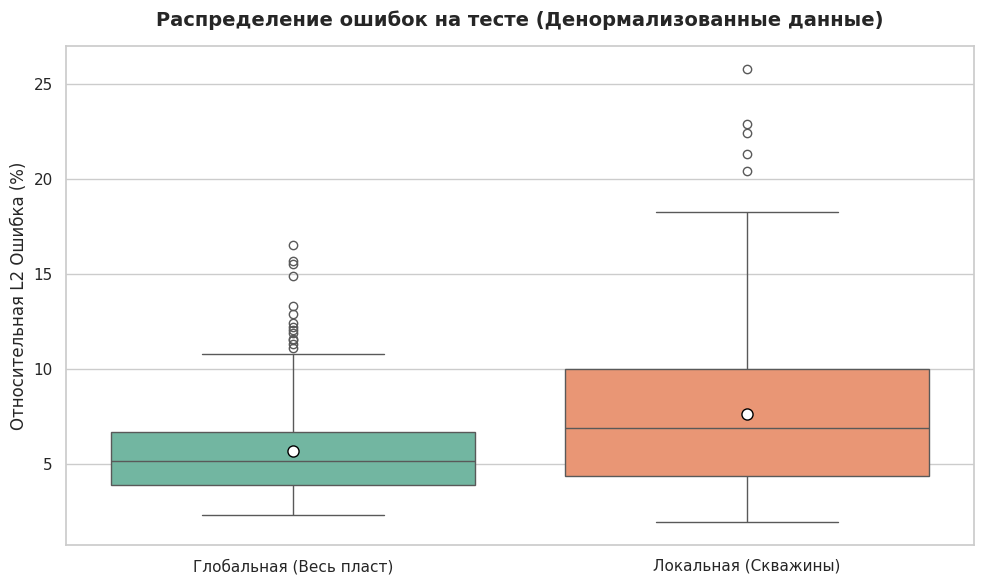

╒═════════════════════════╤══════════════════╤════════════════════╤═══════════════════════╕
│ Зона                    │ Средняя ошибка   │ Медианная ошибка   │ Максимальная ошибка   │
╞═════════════════════════╪══════════════════╪════════════════════╪═══════════════════════╡
│ Глобальная (весь пласт) │ 5.65%            │ 5.14%              │ 16.53%                │
├─────────────────────────┼──────────────────┼────────────────────┼───────────────────────┤
│ Локальная (скважины)    │ 7.64%            │ 6.86%              │ 25.80%                │
╘═════════════════════════╧══════════════════╧════════════════════╧═══════════════════════╛


In [ ]:
import pandas as pd
import seaborn as sns

def evaluate_and_plot_errors(model, test_loader, device, static_mask, p_min, p_max):
    model.eval()
    mask_3d = static_mask.to(device).float().unsqueeze(0).unsqueeze(0).unsqueeze(0)
    
    g_errs = []
    w_errs =[]
    
    with torch.no_grad():
        for batch in test_loader:
            x_in, y_true =[b.to(device) for b in batch]
            B = x_in.size(0)
            
            pred = model(x_in, mask=mask_3d) * mask_3d
            true = y_true * mask_3d
            
            wells_cube = x_in[:, 1:2]
            well_mask = (torch.abs(wells_cube) > 1e-5).float() * mask_3d

            pred_denorm = (pred * (p_max - p_min) + p_min) * mask_3d
            true_denorm = (true * (p_max - p_min) + p_min) * mask_3d
            
            diff_g = torch.norm((pred_denorm - true_denorm).reshape(B, -1), p=2, dim=1)
            true_g = torch.norm(true_denorm.reshape(B, -1), p=2, dim=1)
            g_errs.extend(((diff_g / (true_g + 1e-8)) * 100).cpu().tolist())
            
            diff_w = torch.norm(((pred_denorm - true_denorm) * well_mask).reshape(B, -1), p=2, dim=1)
            true_w = torch.norm((true_denorm * well_mask).reshape(B, -1), p=2, dim=1)
            w_err_batch = (diff_w / (true_w + 1e-8)) * 100
            
            has_wells = well_mask.reshape(B, -1).sum(dim=1) > 0
            w_errs.extend(w_err_batch[has_wells].cpu().tolist())
            
    g_arr = np.array(g_errs)
    w_arr = np.array(w_errs)
    
    df_g = pd.DataFrame({'Зона оценки': 'Глобальная (Весь пласт)', 'Ошибка (%)': g_arr})
    df_w = pd.DataFrame({'Зона оценки': 'Локальная (Скважины)', 'Ошибка (%)': w_arr})
    df_plot = pd.concat([df_g, df_w])
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(
        data=df_plot, x='Зона оценки', y='Ошибка (%)', palette="Set2", 
        showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
    )
    
    plt.title("Распределение ошибок на тесте (Денормализованные данные)", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Относительная L2 Ошибка (%)", fontsize=12)
    plt.xlabel("")
    plt.tight_layout()
    plt.show()
    
    table_data = [["Глобальная (весь пласт)", f"{g_arr.mean():.2f}%", f"{np.median(g_arr):.2f}%", f"{g_arr.max():.2f}%"],["Локальная (скважины)", f"{w_arr.mean():.2f}%", f"{np.median(w_arr):.2f}%", f"{w_arr.max():.2f}%"]
    ]
    
    headers =["Зона", "Средняя ошибка", "Медианная ошибка", "Максимальная ошибка"]
    print(tabulate(table_data, headers=headers, tablefmt="fancy_grid"))

evaluate_and_plot_errors(
    model=model, 
    test_loader=test_loader, 
    device=device, 
    static_mask=STATIC_MASK, 
    p_min=p_min,
    p_max=p_max
)

In [12]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Количество обучаемых параметров: {total_params:,}".replace(',', ' '))
    print(f"В миллионах: {total_params / 1e6:.2f} Млн")
    
    return total_params

count_parameters(model)

Количество обучаемых параметров: 12 809 753
В миллионах: 12.81 Млн


12809753

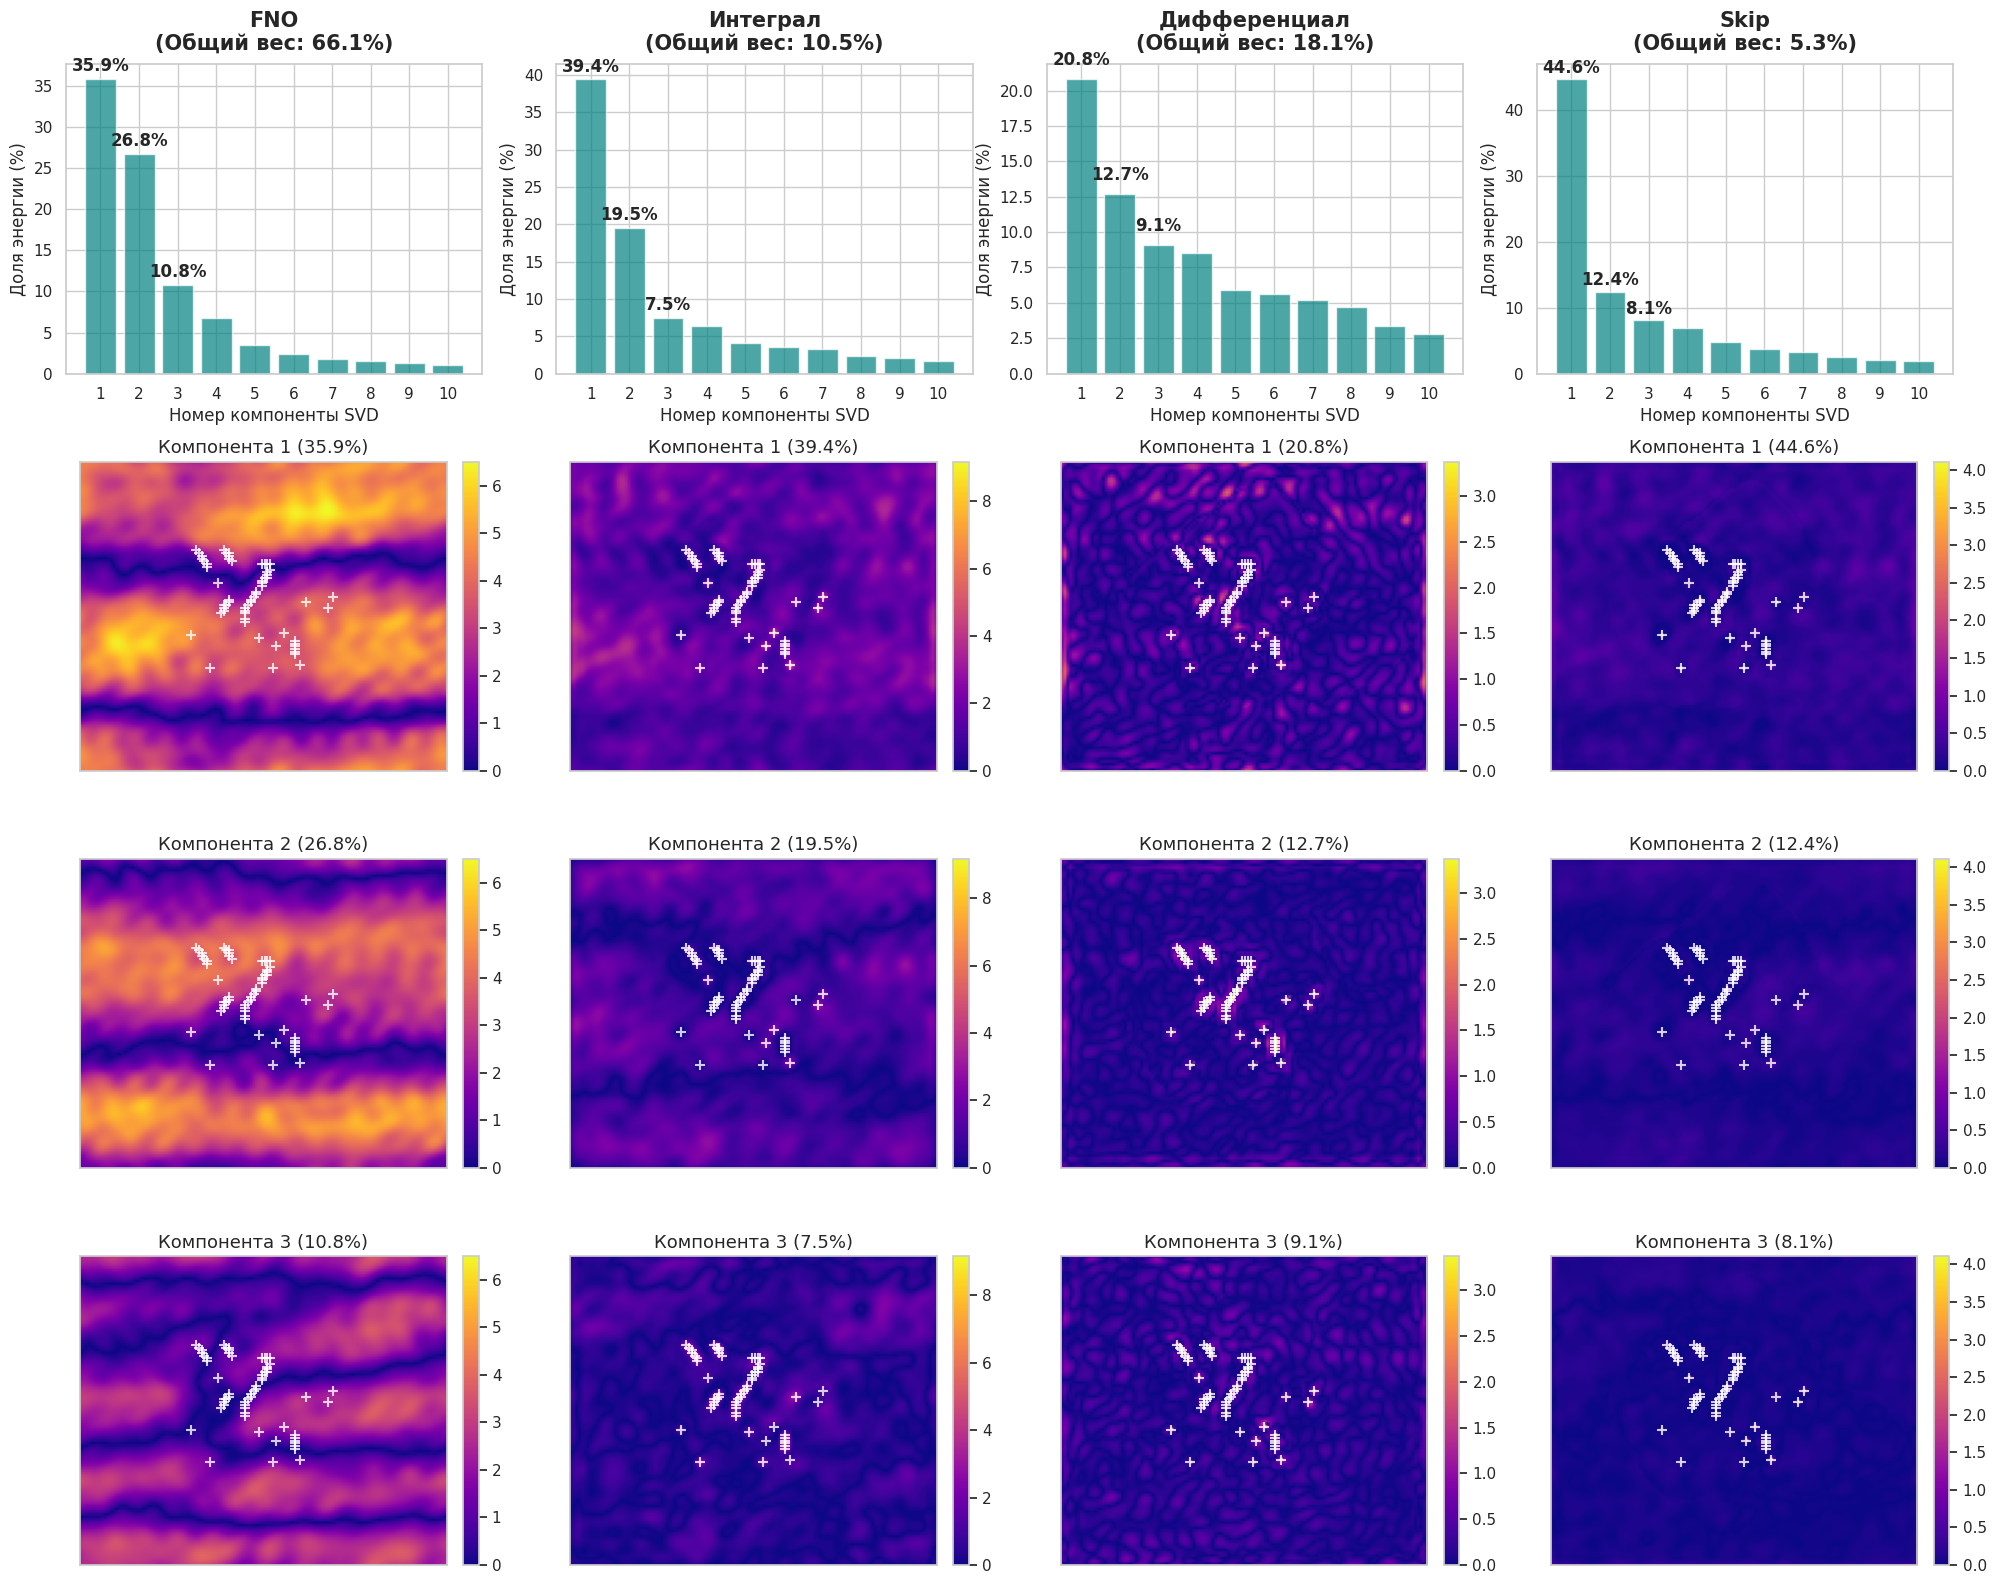

╒══════════════════╤═════════╤════════════╤════════════════╤═════════╕
│ Компонента SVD   │     FNO │   Интеграл │   Дифференциал │    Skip │
╞══════════════════╪═════════╪════════════╪════════════════╪═════════╡
│ Компонента 1     │ 655.307 │   1940.94  │       272.268  │ 744.186 │
├──────────────────┼─────────┼────────────┼────────────────┼─────────┤
│ Компонента 2     │ 565.968 │   1365.58  │       212.574  │ 392.025 │
├──────────────────┼─────────┼────────────┼────────────────┼─────────┤
│ Компонента 3     │ 358.8   │    844.723 │       179.699  │ 316.213 │
├──────────────────┼─────────┼────────────┼────────────────┼─────────┤
│ Компонента 4     │ 283.838 │    783.888 │       174.425  │ 292.455 │
├──────────────────┼─────────┼────────────┼────────────────┼─────────┤
│ Компонента 5     │ 205.377 │    630.018 │       145.268  │ 243.024 │
├──────────────────┼─────────┼────────────┼────────────────┼─────────┤
│ Компонента 6     │ 170.447 │    582.733 │       141.601  │ 216.278 │
├─────

In [ ]:
def attention_map(model, test_loader, device, num_components=3):
    model.eval()
    activations = {}

    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach().cpu()
        return hook

    first_block = model.blocks[0]
    has_diff = hasattr(first_block, 'local_differential')
    
    last_block_idx = len(model.blocks) - 1
    target_block = model.blocks[last_block_idx]
    
    hooks = []
    hooks.append(target_block.fno_conv.register_forward_hook(get_activation('fno')))
    hooks.append(target_block.local_integral.register_forward_hook(get_activation('integral')))
    if has_diff:
        hooks.append(target_block.local_differential.register_forward_hook(get_activation('differential')))
    hooks.append(target_block.skip.register_forward_hook(get_activation('skip')))

    batch = next(iter(test_loader))
    x_in, _ = [b.to(device) for b in batch]
    
    with torch.no_grad():
        _ = model(x_in) 
        
    for h in hooks: h.remove()

    branches = ['fno', 'integral', 'skip']
    titles = ['FNO', 'Интеграл', 'Skip']
    if has_diff:
        branches.insert(2, 'differential')
        titles.insert(2, 'Дифференциал')
        
    n_branches = len(branches)
    t_mid = activations['fno'].shape[2] // 2
    
    raw_s_values = {} 
    
    fig, axes = plt.subplots(num_components + 1, n_branches, figsize=(5 * n_branches, 4 * (num_components + 1)))
    cbar_kwargs = {'fraction': 0.046, 'pad': 0.04}
    
    wells_np = np.abs(x_in[0, 1, t_mid].cpu().numpy())
    well_y, well_x = np.where(wells_np > 1e-5)
    marker_opts = dict(color='white', marker='+', s=60, linewidths=1.5, alpha=0.8)

    fw = torch.softmax(target_block.fusion_weights.detach(), dim=0).cpu().numpy()

    for col_idx, branch_name in enumerate(branches):
        act_tensor = activations[branch_name][0, :, t_mid, :, :]
        C, Y, X = act_tensor.shape
        flat_act = act_tensor.reshape(C, -1)
        
        U, S, Vh = torch.linalg.svd(flat_act, full_matrices=False)
        
        S_numpy = S.numpy()
        raw_s_values[titles[col_idx]] = S_numpy 
        
        energy = (S_numpy**2 / np.sum(S_numpy**2)) * 100
        weight = fw[col_idx]
        
        ax_bar = axes[0, col_idx]
        top_k = min(10, C) 
        ax_bar.bar(range(1, top_k + 1), energy[:top_k], color='teal', alpha=0.7)
        ax_bar.set_title(f"{titles[col_idx]}\n(Общий вес: {weight*100:.1f}%)", fontsize=15, fontweight='bold', pad=10)
        ax_bar.set_xlabel("Номер компоненты SVD")
        ax_bar.set_ylabel("Доля энергии (%)")
        ax_bar.set_xticks(range(1, top_k + 1))
        
        for i in range(num_components):
            ax_bar.text(i + 1, energy[i] + 1, f"{energy[i]:.1f}%", ha='center', fontweight='bold')

        pc1_raw = torch.abs(S[0] * Vh[0]).reshape(Y, X).numpy() * weight
        vmax_column = np.max(pc1_raw) if np.max(pc1_raw) > 1e-8 else 1.0

        for comp_idx in range(num_components):
            ax_img = axes[comp_idx + 1, col_idx]
            
            map_2d = torch.abs(S[comp_idx] * Vh[comp_idx]).reshape(Y, X).numpy() * weight
            
            im = ax_img.imshow(map_2d, cmap='plasma', origin='lower', vmin=0, vmax=vmax_column)
            ax_img.set_title(f"Компонента {comp_idx + 1} ({energy[comp_idx]:.1f}%)", fontsize=13)
            
            ax_img.set_xticks([])
            ax_img.set_yticks([])
            fig.colorbar(im, ax=ax_img, **cbar_kwargs)
            ax_img.scatter(well_x, well_y, **marker_opts)

    plt.tight_layout()
    plt.show()

    table_data = []
    top_k = min(10, C)
    for i in range(top_k):
        row = [f"Компонента {i+1}"]
        for title in titles:
            row.append(f"{raw_s_values[title][i]:.4f}")
        table_data.append(row)
        
    headers = ["Компонента SVD"] + titles
    print(tabulate(table_data, headers=headers, tablefmt="fancy_grid"))

attention_map(model, test_loader, device, num_components=3)

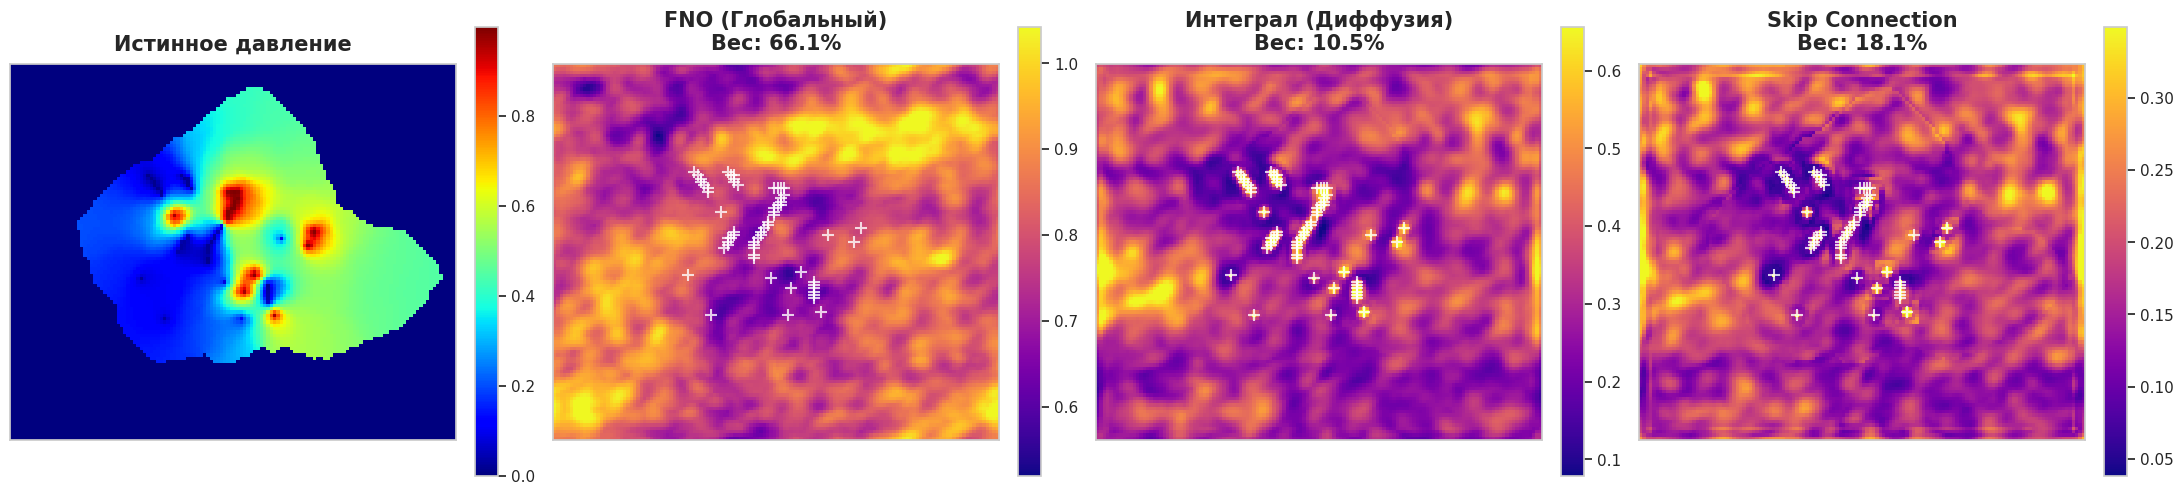

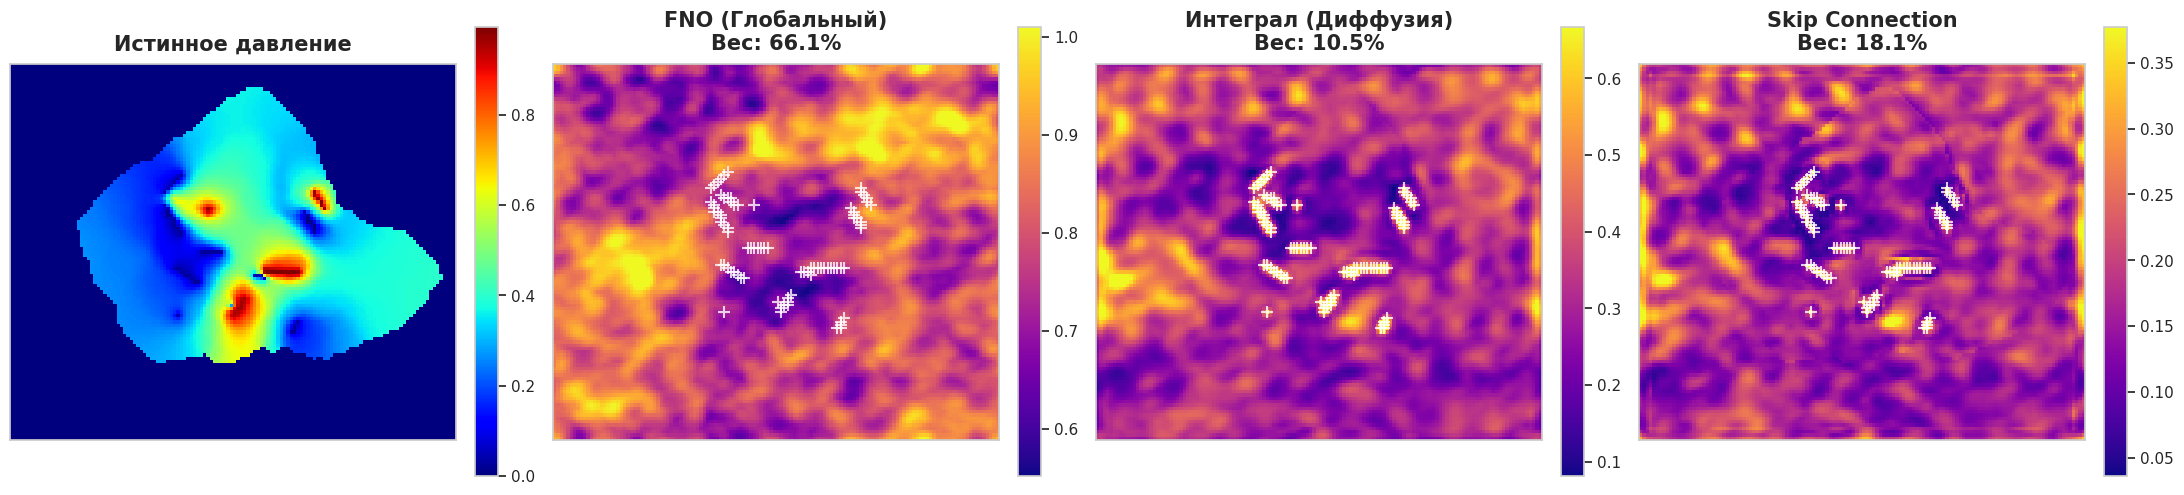

In [ ]:
def visualize_layer_activations_grid(model, test_loader, device, num_samples=3, save_dir="."):
    model.eval()
    activations = {}

    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach().cpu()
        return hook

    last_block_idx = len(model.blocks) - 1
    target_block = model.blocks[last_block_idx]
    
    handle_fno = target_block.fno_conv.register_forward_hook(get_activation('fno'))
    handle_int = target_block.local_integral.register_forward_hook(get_activation('integral'))
    handle_skip = target_block.skip.register_forward_hook(get_activation('skip'))

    batch = next(iter(test_loader))
    x_in, y_true =[b.to(device) for b in batch]
    
    with torch.no_grad():
        _ = model(x_in)
        
    handle_fno.remove()
    handle_int.remove()
    handle_skip.remove()

    act_fno = activations['fno']
    act_int = activations['integral']     
    act_skip = activations['skip']
    
    wells = x_in[:, 1].cpu()              
    true_pressure = y_true[:, 0].cpu()
    
    fw = torch.softmax(target_block.fusion_weights.detach(), dim=0).cpu().numpy()
    weight_fno = fw[0]
    weight_int = fw[1]  
    weight_skip = fw[2]
    
    actual_samples = min(num_samples, x_in.shape[0])
    t_mid = act_int.shape[2] // 2
    cbar_kwargs = {'fraction': 0.046, 'pad': 0.04}
    
    os.makedirs(save_dir, exist_ok=True)

    for i in range(actual_samples):
        fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
        
        map_fno = torch.mean(torch.abs(act_fno[i, :, t_mid, :, :]), dim=0).numpy() * weight_fno
        map_int = torch.mean(torch.abs(act_int[i, :, t_mid, :, :]), dim=0).numpy() * weight_int
        map_skip = torch.mean(torch.abs(act_skip[i, :, t_mid, :, :]), dim=0).numpy() * weight_skip
        
        wells_np = np.abs(wells[i, t_mid].numpy())
        well_y, well_x = np.where(wells_np > 1e-5)
        true_p_np = true_pressure[i, t_mid].numpy()

        vmax_fno = np.percentile(map_fno, 99) if np.max(map_fno) > 1e-8 else 1.0
        vmax_int = np.percentile(map_int, 99) if np.max(map_int) > 1e-8 else 1.0
        vmax_skip = np.percentile(map_skip, 99) if np.max(map_skip) > 1e-8 else 1.0

        marker_opts = dict(color='white', marker='+', s=80, linewidths=1.5, alpha=0.8)

        im0 = axes[0].imshow(true_p_np, cmap='jet', origin='lower')
        axes[0].set_title(f"Истинное давление", fontsize=15, fontweight='bold', pad=10)
        fig.colorbar(im0, ax=axes[0], **cbar_kwargs)

        im1 = axes[1].imshow(map_fno, cmap='plasma', origin='lower', vmax=vmax_fno)
        axes[1].scatter(well_x, well_y, **marker_opts)
        axes[1].set_title(f"FNO (Глобальный)\nВес: {weight_fno*100:.1f}%", fontsize=15, fontweight='bold', pad=10)
        fig.colorbar(im1, ax=axes[1], **cbar_kwargs)

        im2 = axes[2].imshow(map_int, cmap='plasma', origin='lower', vmax=vmax_int)
        axes[2].scatter(well_x, well_y, **marker_opts)
        axes[2].set_title(f"Интеграл (Диффузия)\nВес: {weight_int*100:.1f}%", fontsize=15, fontweight='bold', pad=10)
        fig.colorbar(im2, ax=axes[2], **cbar_kwargs)

        im3 = axes[3].imshow(map_skip, cmap='plasma', origin='lower', vmax=vmax_skip)
        axes[3].scatter(well_x, well_y, **marker_opts)
        axes[3].set_title(f"Skip Connection\nВес: {weight_skip*100:.1f}%", fontsize=15, fontweight='bold', pad=10)
        fig.colorbar(im3, ax=axes[3], **cbar_kwargs)

        for ax in axes:
            ax.set_xticks([])
            ax.set_yticks([])

        plt.tight_layout()

    plt.show()
    

visualize_layer_activations_grid(model, test_loader, device)